In [1]:
from segment_anything import sam_model_registry, SamPredictor
import torch

sam = sam_model_registry["vit_b"](
    checkpoint="sam_vit_b.pth"   # works because exists == True
)

device = "cuda" if torch.cuda.is_available() else "cpu"
sam.to(device)

predictor = SamPredictor(sam)

print("✅ SAM loaded successfully")


✅ SAM loaded successfully


In [2]:
predictor.set_image(image_clahe)


NameError: name 'image_clahe' is not defined

In [3]:
import numpy as np
import matplotlib.pyplot as plt

h, w, _ = image_clahe.shape

point_coords = np.array([[w//2, h//2]])
point_labels = np.array([1])  # foreground

masks, scores, _ = predictor.predict(
    point_coords=point_coords,
    point_labels=point_labels,
    multimask_output=True
)

mask = masks[scores.argmax()]

plt.imshow(image_clahe)
plt.imshow(mask, alpha=0.5)
plt.title("SAM sanity check")
plt.axis("off")


NameError: name 'image_clahe' is not defined

(np.float64(-0.5), np.float64(1599.5), np.float64(1065.5), np.float64(-0.5))

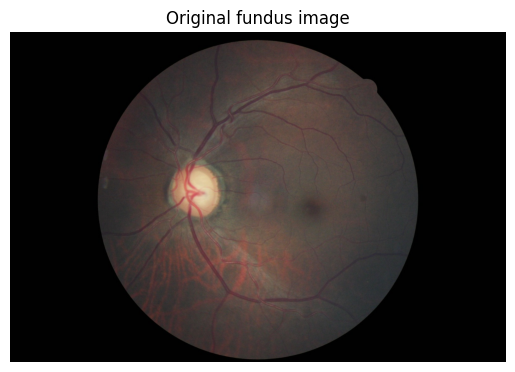

In [5]:
import cv2
import matplotlib.pyplot as plt

# CHANGE this filename to your image name
img_path = "retina.jpg"

image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title("Original fundus image")
plt.axis("off")


(np.float64(-0.5), np.float64(1599.5), np.float64(1065.5), np.float64(-0.5))

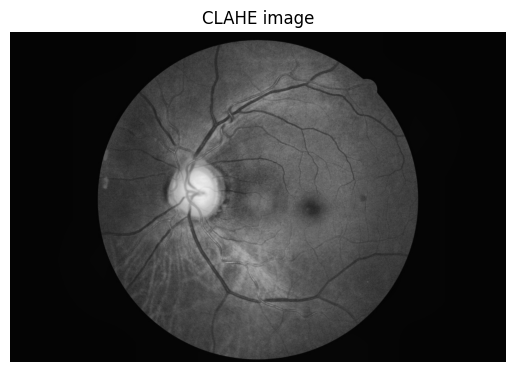

In [6]:
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
clahe_img = clahe.apply(gray)

image_clahe = cv2.cvtColor(clahe_img, cv2.COLOR_GRAY2RGB)

plt.imshow(image_clahe)
plt.title("CLAHE image")
plt.axis("off")


In [7]:
predictor.set_image(image_clahe)


(np.float64(-0.5), np.float64(1599.5), np.float64(1065.5), np.float64(-0.5))

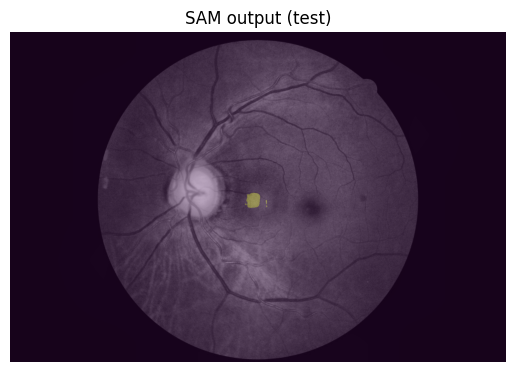

In [33]:
import numpy as np
import matplotlib.pyplot as plt

h, w, _ = image_clahe.shape

# one foreground point (center)
point_coords = np.array([[w//2, h//2]])
point_labels = np.array([1])

masks, scores, _ = predictor.predict(
    point_coords=point_coords,
    point_labels=point_labels,
    multimask_output=True
)

mask = masks[np.argmax(scores)]

plt.imshow(image_clahe)
plt.imshow(mask, alpha=0.3)
plt.title("SAM output (test)")
plt.axis("off")


In [9]:
import numpy as np

gray = cv2.cvtColor(image_clahe, cv2.COLOR_RGB2GRAY)

h, w = gray.shape
center = (w//2, h//2)

# create circular ring region (RNFL zone)
Y, X = np.ogrid[:h, :w]
dist = np.sqrt((X-center[0])**2 + (Y-center[1])**2)

rnfl_ring = np.logical_and(dist > 80, dist < 150)

ys, xs = np.where(rnfl_ring)

idx = np.random.choice(len(xs), size=20, replace=False)
sam_points = np.column_stack((xs[idx], ys[idx]))
sam_labels = np.ones(len(sam_points))


In [22]:
masks, scores, _ = predictor.predict(
    point_coords=sam_points,
    point_labels=sam_labels,
    multimask_output=True
)

rnfl_mask = masks[np.argmax(scores)].astype(np.uint8)


In [23]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
rnfl_mask = cv2.morphologyEx(rnfl_mask, cv2.MORPH_CLOSE, kernel)


(np.float64(-0.5), np.float64(1599.5), np.float64(1065.5), np.float64(-0.5))

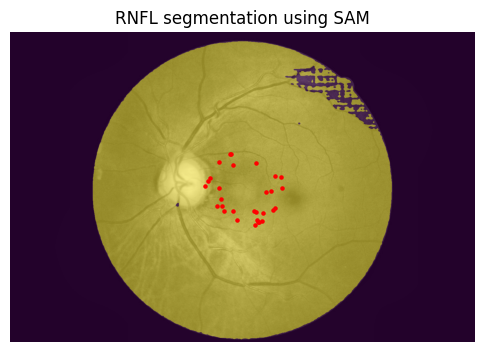

In [24]:
plt.figure(figsize=(6,6))
plt.imshow(image_clahe)
plt.imshow(rnfl_mask, alpha=0.5)
plt.scatter(sam_points[:,0], sam_points[:,1], c='red', s=5)
plt.title("RNFL segmentation using SAM")
plt.axis("off")


In [25]:
import cv2
import numpy as np

# Convert to grayscale if not already
gray = cv2.cvtColor(image_clahe, cv2.COLOR_RGB2GRAY)

# Use morphological top-hat filter to suppress bright vessels
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
vessels = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, kernel)

# Subtract vessels to suppress them
rnfl_input = cv2.subtract(gray, vessels)

# Convert back to RGB for SAM
rnfl_input_rgb = cv2.cvtColor(rnfl_input, cv2.COLOR_GRAY2RGB)
predictor.set_image(rnfl_input_rgb)


In [14]:
h, w = gray.shape
center = (w//2, h//2)  # assume optic disc near center
Y, X = np.ogrid[:h, :w]

# Circular ring around optic disc
dist = np.sqrt((X-center[0])**2 + (Y-center[1])**2)
rnfl_zone = np.logical_and(dist > 80, dist < 140)  # adjust radii

ys, xs = np.where(rnfl_zone)

# Reduce number of points for SAM
idx = np.random.choice(len(xs), size=30, replace=False)
sam_points = np.column_stack((xs[idx], ys[idx]))
sam_labels = np.ones(len(sam_points))


In [15]:
masks, scores, _ = predictor.predict(
    point_coords=sam_points,
    point_labels=sam_labels,
    multimask_output=True
)

rnfl_mask = masks[np.argmax(scores)].astype(np.uint8)


In [16]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
rnfl_mask = cv2.morphologyEx(rnfl_mask, cv2.MORPH_CLOSE, kernel)

# Optional: keep only the largest connected component
num_labels, labels_im = cv2.connectedComponents(rnfl_mask)
sizes = [np.sum(labels_im==i) for i in range(1, num_labels)]
if sizes:
    largest_label = np.argmax(sizes)+1
    rnfl_mask = (labels_im==largest_label).astype(np.uint8)


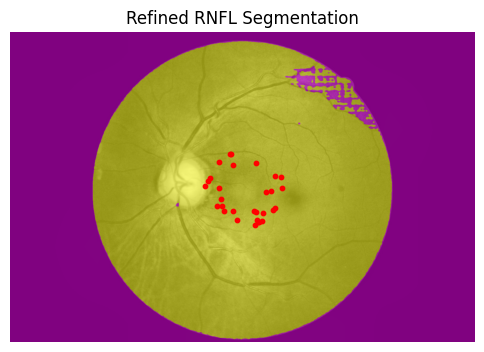

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(image_clahe)
plt.imshow(rnfl_mask, alpha=0.5, cmap='spring')
plt.scatter(sam_points[:,0], sam_points[:,1], c='red', s=10)
plt.title("Refined RNFL Segmentation")
plt.axis("off")
plt.show()
